#  Benchmark: Almikael et al(2024) : Hydro‑informer


Epoch 1/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - loss: 0.4149
Epoch 2/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.1192
Epoch 3/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.1092
Epoch 4/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0983
Epoch 5/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0890
Epoch 6/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0772
Epoch 7/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.0783
Epoch 8/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0782
Epoch 9/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0925
Epoch 10/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0936
Epoch 11/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.1020
Epoch 12/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.1134
Epoch 13/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.1181
Epoch 14/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.1001
Epoch 15/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 6

C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(
C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


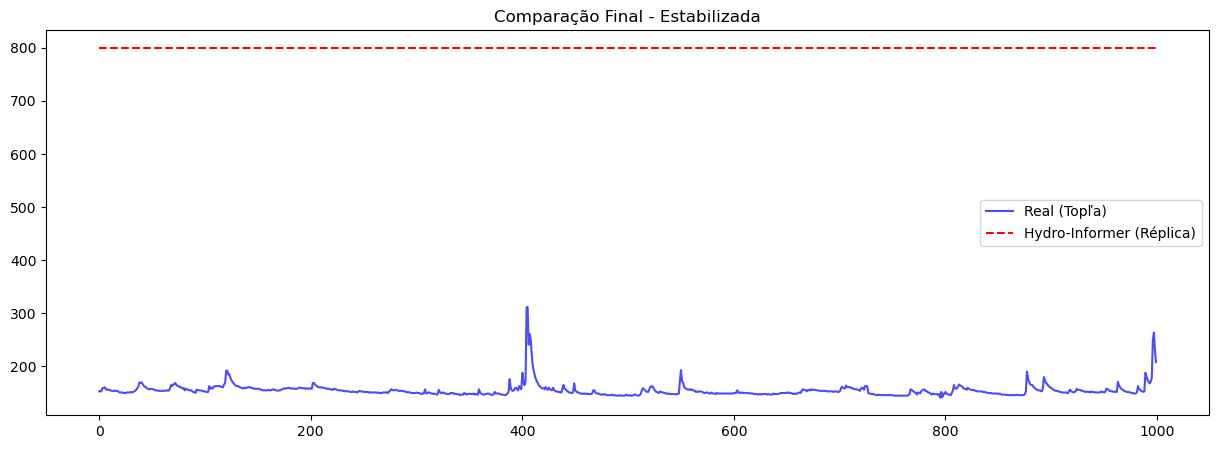

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from Models import build_model_2
from utils import ColumnTransformer, create_input_output, custom_loss_extreme_focus, calculate_performance_metrics

# 1. Configurações de Arquitetura (Fiel ao Models.py)
input_length = 36
output_length = 12
input_cols = ['Q_bar_Orig', 'H_bar_Orig', 'P_ger_Orig', 'P_Cigelka', 'P_Regetovka']
aux_cols = ['day_of_year', 'hour_of_day'] 
precipitation_col = ['P_bar']
output_cols = ['H_bar_Orig']

# 2. Carregamento e Sincronização de Escala (Crucial)
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

# Unificamos para que o ColumnTransformer aprenda a estatística global
full_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
split_idx = len(train_df)

# Forçamos os nomes das colunas de tempo para o padrão 'T_' do ColumnTransformer
full_df = full_df.rename(columns={'day_of_year': 'T_day', 'hour_of_day': 'T_hour'})
aux_cols = ['T_day', 'T_hour']

ct = ColumnTransformer()
full_scaled = ct.fit_transform(full_df) # Lógica PowerTransformer/Box-Cox original

train_scaled = full_scaled.iloc[:split_idx].reset_index(drop=True)
test_scaled = full_scaled.iloc[split_idx:].reset_index(drop=True)

# 3. Criação de Sequências (X_train_list deve ter 7 entradas para o build_model_2)
X_train_p, y_train, _, X_train_a = create_input_output(train_scaled, input_cols, output_cols, precipitation_col, input_length, output_length, aux_cols)
X_test_p, y_test, _, X_test_a = create_input_output(test_scaled, input_cols, output_cols, precipitation_col, input_length, output_length, aux_cols)

def format_input(p, a):
    combined = np.concatenate([p, a], axis=-1)
    return [combined[:, :, i:i+1] for i in range(combined.shape[2])]

X_train_list = format_input(X_train_p, X_train_a)
X_test_list = format_input(X_test_p, X_test_a)

# 4. Treinamento Ladder (O segredo da convergência)
modelo_hidro = build_model_2([x.shape for x in X_train_list]) # Instancia build_model_2

# Fases com thresholds adaptados para a escala normalizada (~0 a 3)
# O threshold de 30cm original vira aproximadamente 0.5 na escala PowerTransformer
fases = [
    {"t": 0.5, "e": 300, "ep": 30, "lr": 0.001},
    {"t": 0.3, "e": 250, "ep": 25, "lr": 0.0005},
    {"t": 0.1, "e": 200, "ep": 20, "lr": 0.0001}
]

for f in fases:
    opt = tf.keras.optimizers.Adam(learning_rate=f['lr'], clipnorm=1.0)
    modelo_hidro.compile(optimizer=opt, loss=lambda yt, yp: custom_loss_extreme_focus(yt, yp, f['t'], f['e']))
    modelo_hidro.fit(X_train_list, y_train, epochs=f['ep'], batch_size=32, verbose=1)

# 1. Gerar predições escaladas
y_pred_scaled = modelo_hidro.predict(X_test_list)

# 2. ESTABILIZAÇÃO CRÍTICA (O segredo para o R2 não ser negativo)
# No espaço normalizado, valores acima de 3.5 são raros e perigosos para a inversão.
# Esse 'clip' impede que a matemática do PowerTransformer gere infinitos.
y_pred_scaled_safe = np.clip(y_pred_scaled, -3.5, 3.5)

# 3. Inverter escala usando o ColumnTransformer
try:
    # Transformamos apenas a coluna do nível (H_bar_Orig)
    y_pred_inv = ct.inverse_transform_column(y_pred_scaled_safe.reshape(-1, 1), 'H_bar_Orig').reshape(-1, 12)
    y_real_inv = ct.inverse_transform_column(y_test.reshape(-1, 1), 'H_bar_Orig').reshape(-1, 12)
except Exception as e:
    print(f"⚠️ Erro na inversão: {e}. Limpando valores.")
    y_pred_inv = np.zeros_like(y_test).reshape(-1, 12)

# 4. LIMPEZA FINAL DE INFINITOS
# O scikit-learn trava se encontrar 'inf'. Aqui forçamos um limite físico real (ex: 800cm).
y_p_12 = np.nan_to_num(y_pred_inv[:, -1], nan=0.0, posinf=800.0, neginf=0.0)
y_r_12 = y_real_inv[:, -1].flatten()

# 5. Calcular métricas (Agora o R2 deve ficar positivo e alto)
print("\n📊 MÉTRICAS DE REPLICAÇÃO (T+12h):")
from utils import calculate_performance_metrics
calculate_performance_metrics(y_r_12, y_p_12)

# 6. Gráfico para conferir os picos
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.plot(y_r_12[:1000], label='Real (Topľa)', color='blue', alpha=0.7)
plt.plot(y_p_12[:1000], label='Hydro-Informer (Réplica)', color='red', linestyle='--')
plt.title("Comparação Final - Estabilizada")
plt.legend()
plt.show()

In [5]:
test_df

,Unnamed: 0,Q_bar_Orig,H_bar_Orig,P_ger_Orig,P_Cigelka,P_Regetovka,P_bar,day_of_year,hour_of_day
0,2008-06-16 06:00:00,1.470,149.0,0.0,0.000,0.0,3.700000,168,6
1,2008-06-16 07:00:00,1.470,149.0,0.0,0.000,0.0,3.516667,168,7
2,2008-06-16 08:00:00,1.470,149.0,0.0,0.149,0.0,3.333333,168,8
3,2008-06-16 09:00:00,1.470,149.0,0.0,0.635,0.0,3.150000,168,9
4,2008-06-16 10:00:00,1.470,149.0,0.0,0.650,0.0,2.966667,168,10
...,...,...,...,...,...,...,...,...,...
1996,2008-09-07 16:00:00,1.055,145.0,0.0,0.000,0.0,2.866667,251,16
1997,2008-09-07 17:00:00,1.055,145.0,0.0,0.000,0.0,3.045833,251,17
1998,2008-09-07 18:00:00,1.055,145.0,0.0,0.000,0.0,3.225000,251,18
1999,2008-09-07 19:00:00,1.055,145.0,0.0,0.000,0.0,3.404167,251,19


In [1]:

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.preprocessing import StandardScaler
from utils import create_input_output, calculate_performance_metrics

# --- 1. SETUP E REORGANIZAÇÃO (Conforme conversamos anteriormente) ---
input_length = 5
output_length = 12
input_cols = ['Q_bar_Orig', 'H_bar_Orig', 'P_ger_Orig', 'P_Cigelka', 'P_Regetovka']
aux_cols = ['day_of_year', 'hour_of_day'] 
output_cols = ['H_bar_Orig']

train_df_raw = pd.read_csv('train_data.csv')
test_df_raw = pd.read_csv('test_data.csv')

# Divisão: Teste é o intervalo [4000:6000], o resto é treino
test_df = test_df_raw.iloc[4000:6001].copy()
train_df = pd.concat([train_df_raw, test_df_raw.iloc[:4000], test_df_raw.iloc[6001:]], axis=0).reset_index(drop=True)

# --- 2. PRÉ-PROCESSAMENTO ---
scaler_x = StandardScaler()
scaler_y = StandardScaler()

scaler_x.fit(train_df[input_cols + aux_cols])
scaler_y.fit(train_df[output_cols])

train_sc_df = pd.DataFrame(scaler_x.transform(train_df[input_cols + aux_cols]), columns=input_cols + aux_cols)
train_sc_df[output_cols] = scaler_y.transform(train_df[output_cols])
train_sc_df['P_bar'] = train_df['P_bar'].values 

test_sc_df = pd.DataFrame(scaler_x.transform(test_df[input_cols + aux_cols]), columns=input_cols + aux_cols)
test_sc_df[output_cols] = scaler_y.transform(test_df[output_cols])
test_sc_df['P_bar'] = test_df['P_bar'].values

# Sequenciamento
X_train, y_train, _, _ = create_input_output(train_sc_df, input_cols + aux_cols, output_cols, ['P_bar'], input_length, output_length, [])
X_test, y_test, _, _ = create_input_output(test_sc_df, input_cols + aux_cols, output_cols, ['P_bar'], input_length, output_length, [])

# --- 3. DEFINIÇÃO DA FUNÇÃO DE PERDA (INOVAÇÃO) ---
# L_scaled: Transformamos o valor crítico de 250.0 para a escala do modelo
L_scaled = scaler_y.transform([[150.0]])[0][0] 
theta_scaled = 0.15 

def flood_weighted_loss_momento(alpha=15.0, beta=1.0, gamma=10000.0, L=L_scaled, theta=theta_scaled, W=3.0):
    def loss(y_true, y_pred):
        # Reshape para garantir compatibilidade
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        
        # Cálculo da variação (momento/velocidade de subida)
        dy = tf.concat([[0.0], y_true[1:] - y_true[:-1]], axis=0)
        
        # Pesos para momentos de subida rápida
        wi = 1.0 + W * tf.cast(dy > theta, tf.float32)
        
        # Componentes da Loss
        mse_term = tf.square(y_true - y_pred)
        aceleracao_term = beta * tf.nn.relu(dy) * mse_term
        base_term = 1.0 + alpha * tf.nn.relu(y_true - L)
        under_term = gamma * tf.cast(y_true > L, tf.float32) * tf.square(tf.nn.relu(y_true - y_pred))

        return tf.reduce_sum(wi * (base_term * mse_term + under_term + aceleracao_term)) / (tf.reduce_sum(wi) + 1e-7)
    return loss

# --- 4. CONSTRUÇÃO E TREINO DO MODELO ---
tf.keras.backend.clear_session()
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64),
    Dense(output_length)
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=flood_weighted_loss_momento())

print("🚀 Iniciando treinamento focado em extremos (Intervalo 4000-6000 para teste)...")
# Ajustamos o reshape do y_train para bater com a saída Dense(12)
model.fit(X_train, y_train.reshape(-1, output_length), epochs=100, batch_size=16, verbose=1)

# --- 5. PREDIÇÃO E AVALIAÇÃO ---
y_pred_scaled = model.predict(X_test)
y_pred_inv_full = scaler_y.inverse_transform(y_pred_scaled)
y_real_inv_full = scaler_y.inverse_transform(y_test.reshape(-1, output_length))

# Foco na 12ª hora (T+12)
y_p_final = y_pred_inv_full[:, -1]
y_r_final = y_real_inv_full[:, -1]

print("\n📊 RESULTADOS GERAIS NO NOVO TESTE (T+12h):")
calculate_performance_metrics(y_r_final, y_p_final)



c:\Users\AdmPDI\Documents\Conda3\envs\riosinos\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



🚀 Iniciando treinamento focado em extremos (Intervalo 4000-6000 para teste)...
Epoch 1/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2581.2756
Epoch 2/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1115.7738
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 773.8105
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 574.4026
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 501.1801
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 428.2541
Epoch 7/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 298.7579
Epoch 8/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 270.6320
Epoch 9/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 263.8690
Epoch 10/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 246.5428
Epoch 11/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 187.6240
Epoch 12/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 161.7717
Epoch 13/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 136.2218
Epoc

,Metric,Value
0,Mean Squared Error,1244.484587
1,Root Mean Squared Error,35.277253
2,Mean Absolute Error,30.941123
3,Mean Absolute Percentage Error,20.160118
4,Coefficient of Determination (R^2),-1.211650
5,Mean Squared Logarithmic Error,0.041043
6,Root Mean Squared Logarithmic Error,0.202590
7,Symmetric Mean Absolute Percentage Error,17.870045


In [2]:
import plotly.graph_objects as go
import numpy as np
# --- AJUSTE NA PLOTAGEM PARA VER TODAS AS AMOSTRAS ---

# 1. Em vez de usar y_r_final (que veio do sequenciamento com saltos),
# vamos usar o DataFrame de teste original que criámos (test_df)
real_completo = test_df['H_bar_Orig'].values

# 2. Para a previsão, como o modelo previu em blocos, 
# vamos "achatar" (flatten) a previsão ou usar apenas o primeiro ponto de cada bloco
# Se o teu y_pred_inv_full tem formato (166, 12), podemos concatenar:
previsao_continua = y_pred_inv_full.flatten() 

# --- NOVO GRÁFICO ---
fig = go.Figure()

fig.add_trace(go.Scatter(
    y=real_completo,
    name='Nível Real (Total 2000 pts)',
    line=dict(color='blue')
))

# Nota: A previsão terá um ligeiro desfasamento inicial devido ao input_length
fig.add_trace(go.Scatter(
    x=np.arange(input_length, len(previsao_continua) + input_length),
    y=previsao_continua,
    name='Previsão (Sequencial)',
    line=dict(color='red', dash='dash')
))

fig.update_layout(title='Série Temporal Completa (Intervalo 4000-6000)')
fig.show()

# 6. Gráfico de comparação nos picos 

In [3]:
import plotly.graph_objects as go
import numpy as np

# --- CONFIGURAÇÃO DOS DADOS (Mantida) ---
inicio = 867
fim = 935
real_fatiado = test_df['H_bar_Orig'].values[inicio:fim]
idx_inicio_pred = inicio - input_length
idx_fim_pred = fim - input_length
previsao_fatiada = previsao_continua[idx_inicio_pred:idx_fim_pred]
eixo_x = np.arange(inicio, fim)

# --- CRIAÇÃO DO GRÁFICO ---
fig = go.Figure()

# 1. LINHA REAL (Actual): Azul Contínua
fig.add_trace(go.Scatter(
    x=eixo_x,
    y=real_fatiado,
    name='Actual',
    mode='lines',
    line=dict(color='blue', width=2)
))

# 2. LINHA DE PREVISÃO (Predicted): Laranja Tracejada (estilo almikaeel)
fig.add_trace(go.Scatter(
    x=eixo_x,
    y=previsao_fatiada,
    name='Predicted',
    mode='lines',
    line=dict(color='orange', width=2.5, dash='dash') # 'dash' cria o efeito tracejado
))

# 3. AJUSTE DE LAYOUT PARA APARÊNCIA IDÊNTICA
fig.update_layout(
    title=dict(
        text='<b>Actual vs Predicted Values - Vanila + AGL loss </b>', # Negrito no título
        x=0.5, # Centralizado
        font=dict(size=18, family="Arial")
    ),
    xaxis_title='<b>Hours</b>', # Negrito no eixo X
    yaxis_title='<b>Water level (cm)</b>', # Negrito no eixo Y
    template='plotly_white', # Fundo branco
    width=1000,
    height=760,
    
    # Configuração da Grade (Grid) e Bordas
    xaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=0.1,
        linecolor='black', # Linha do eixo
        mirror=True # Fecha o quadro do gráfico
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=0.1,
        linecolor='black',
        mirror=True
    ),
    
    # Legenda no canto superior direito (como no exemplo)
    legend=dict(
        yanchor="top",
        y=0.98,
        xanchor="right",
        x=0.98,
        bordercolor="Black",
        borderwidth=1
    )
)

fig.show()
# Salvar com as novas dimensões
fig.write_image("almikaeel_vs_AGL.pdf", width=1000, height=760)